## Architecture


    UNLABELED SINGLE MANUFACTURING CYCLE (Snapshot)
                                     │
                  ┌──────────────────┴──────────────────┐
                  │                                     │
                View 1                                View 2
          (Available Sensors)                    (Masked Sensors)
                  │                                     │
                  ↓                                     ↓
          Shared MLP Encoder                    Shared MLP Encoder
                  │                                     │
                  ↓                                     ↓
          z1 (Context Embedding)                z2 (Target Embedding)
                  │                                     │
                  ↓                                     │
            LeJEPA Predictor                            │
                  │                                     │
                  ↓                                     │
    z2_pred (Predicted Target Embedding)                │ (Stop-Gradient)
                  │                                     │
                  └──────────────────┬──────────────────┘
                                     ↓
                            Invariance + SIGReg
                    (Loss: MSE + Variance Regularization)
                                      │
    ══════════════════════════════════│═════════════════════════════════════
    DOWNSTREAM TASKS                  │
                                      ↓
      ┌──────────────────────────────────────────────────────────────┐
      │                   ACTIVE LEARNING LOOP                       │
      │                                                              │
      │ INPUTS RECEIVED:                                             │
      │ 1. Trained Encoder      ─────────┐                           │
      │ 2. Trained Predictor    ─────────┼─> Calculate Latent Error  │
      │ 3. X_tensor (Full Data) ─────────┘   (Distance: z_target vs  │
      │                                       z_pred on 50% mask)    │
      │                                              │               │
      │                                              ↓               │
      │                      Query Indices (Top 300 uncertain cycles)│
      │                                              │               │
      │                                              ↓               │
      │                            Train RandomForest Classifier     │
      └──────────────────────────────────────────────┬───────────────┘
                                                     │
                                                     ↓
      ┌──────────────────────────────────────────────────────────────┐
      │                   EXPLAINABILITY (SHAP)                      │
      │                                                              │
      │ INPUTS RECEIVED:                                             │
      │ 1. Trained Classifier (RandomForest) ───┐                    │
      │ 2. X_active_learning (Queried Raw Data) ┼─> TreeExplainer    │
      │                                         │                    │
      │                                         ↓                    │
      │                        SHAP Values (Feature Attributions)    │
      │                                         │                    │
      │                                         ↓                    │
      │                           Physical Operating Window &        │
      │                           Global Importance Reports          │
      └──────────────────────────────────────────────────────────────┘



## Imports and Data Preprocessing
This cell handles loading the dataset, dropping non-sensor metadata, handling class imbalance conceptually, and converting the raw features into standardized PyTorch tensors.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc




c:\Users\Iman\Desktop\CIRP Conference Study\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# CELL 1: Data Preprocessing
# ==========================================

# 1. Load the dataset
df = pd.read_csv('../data/labeled_data_preprocessed.csv')

# 2. Separate features and target, dropping metadata and null-heavy columns
features_to_drop = ['_id', 'TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD', 'EQUIP_NAME', 'Reason', 'PassOrFail']

X = df.drop(columns=features_to_drop)
y = df['PassOrFail'].values
feature_names = X.columns.tolist()

# 3. Standardize the features (Critical for isotropic regularization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Convert to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

print(f"Dataset Loaded. Shape: {X_tensor.shape}")
print(f"Total Defects (PassOrFail=1): {sum(y)} out of {len(y)}")

Dataset Loaded. Shape: torch.Size([5232, 26])
Total Defects (PassOrFail=1): 60 out of 5232


<br> <br> <br>

## Cell 2: Intra-Cycle LeJEPA Architecture

This defines the simple, shared Multi-Layer Perceptron (MLP) encoder and the predictor network, along with the Sketched Isotropic Gaussian Regularization (SIGReg) loss function.

In [3]:
# ==========================================
# CELL 2: LeJEPA Model Definition
# ==========================================
class LeJEPAEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()
        # Permutation-invariant MLP for intra-cycle features
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        
    def forward(self, x):
        return self.net(x)

class LeJEPAPredictor(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        
    def forward(self, z):
        return self.net(z)

def sigreg_loss(z_target, z_pred, variance_epsilon=1e-4):
    """
    Combines MSE prediction loss with variance regularization 
    to prevent latent space collapse (enforcing isotropic Gaussian).
    """
    # 1. Prediction error
    mse_loss = torch.mean((z_target - z_pred)**2)
    
    # 2. Variance regularization across the batch for the target embeddings
    var_z = torch.var(z_target, dim=0)
    std_loss = torch.mean(torch.relu(1 - var_z + variance_epsilon))
    
    # Combine with a weighting factor (hyperparameter to tune)
    return mse_loss + 0.1 * std_loss

<br> <br> <br>

## Cell 3: Self-Supervised Pre-training (Feature Masking)


This cell executes the intra-cycle masking. We randomly drop out roughly 50% of the sensors to create View 1 (the context) and use the complementary sensors as View 2 (the target), training the model to predict the missing physics of the cycle.

In [4]:
# ==========================================
# CELL 3: Intra-Cycle Pre-training 
# ==========================================
input_dim = X_tensor.shape[1]
latent_dim = 32

encoder = LeJEPAEncoder(input_dim, latent_dim)
predictor = LeJEPAPredictor(latent_dim)
optimizer = optim.Adam(list(encoder.parameters()) + list(predictor.parameters()), lr=1e-3)

epochs = 500 
batch_size = 256
dataset = torch.utils.data.TensorDataset(X_tensor)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

encoder.train()
predictor.train()

print("Starting LeJEPA Pre-training...")
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch in dataloader:
        x_batch = batch[0]
        optimizer.zero_grad()
        
        # Intra-cycle Feature Masking: Randomly mask ~50% of sensors
        mask = (torch.rand_like(x_batch) > 0.5).float()
        
        # View 1: Available context
        view1 = x_batch * mask
        # View 2: The missing features we want to predict
        view2 = x_batch * (1 - mask)
        
        # Encode both views
        z1 = encoder(view1)
        z2 = encoder(view2)
        
        # Predict View 2's latent state from View 1's latent state
        z2_pred = predictor(z1)
        
        # Calculate loss (detach z2 to stop gradients flowing through the target branch)
        loss = sigreg_loss(z2.detach(), z2_pred)
        
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    if (epoch + 1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(dataloader):.4f}")

print("Pre-training complete.")

Starting LeJEPA Pre-training...
Epoch [25/500], Loss: 0.1482
Epoch [50/500], Loss: 0.0999
Epoch [75/500], Loss: 0.1027
Epoch [100/500], Loss: 0.0935
Epoch [125/500], Loss: 0.0747
Epoch [150/500], Loss: 0.0724
Epoch [175/500], Loss: 0.0537
Epoch [200/500], Loss: 0.0501
Epoch [225/500], Loss: 0.0532
Epoch [250/500], Loss: 0.0437
Epoch [275/500], Loss: 0.0505
Epoch [300/500], Loss: 0.0381
Epoch [325/500], Loss: 0.0437
Epoch [350/500], Loss: 0.0418
Epoch [375/500], Loss: 0.0343
Epoch [400/500], Loss: 0.0361
Epoch [425/500], Loss: 0.0361
Epoch [450/500], Loss: 0.0398
Epoch [475/500], Loss: 0.0360
Epoch [500/500], Loss: 0.0475
Pre-training complete.


#### Note:

- If **optimizer.zero_grad()** is omitted, the gradients from every mini-batch continuously add to the gradients of all previous mini-batches . Consequently, when optimizer.step() runs, parameter updates would be scaled in magnitude by past steps and point in an unintended direction, typically leading to divergence or unstable training .

- **loss = sigreg_loss(z2.detach(), z2_pred)** computes the discrepancy between the latent representation of the missing sensors and the prediction derived from the context sensors.

- **loss.backward()** calculates the partial derivatives of that loss with respect to the trainable weights of encoder and predictor .

- **Calling optimizer.zero_grad()** at the start of each iteration ensures that optimizer.step() applies updates computed solely on the current mini-batch .

In [5]:
# ==========================================
# DEBUGGING CELL: Visualize the Views 
# ==========================================
import pandas as pd

# Grab just the very first cycle (snapshot) to visualize
x_sample = X_tensor[0:1] # Shape: (1, 26)
print(x_sample, "\n\n\n\n")
# Set random seed just for this visualization so it doesn't change every time you run it
torch.manual_seed(42)

# Apply the masking logic exactly as it is in the training loop
mask = (torch.rand_like(x_sample) > 0.5).float()
view1 = x_sample * mask
view2 = x_sample * (1 - mask)

# Convert back to a readable pandas DataFrame
visualize_df = pd.DataFrame({
    'Sensor Name': feature_names,
    'Original (Scaled)': x_sample[0].numpy(),
    'Mask (1=Keep, 0=Drop)': mask[0].numpy(),
    'View 1 (Context)': view1[0].numpy(),
    'View 2 (Target)': view2[0].numpy()
})

print(visualize_df.round(4).to_string(index=False))

tensor([[ 0.5653,  0.5766,  0.5961, -0.5581,  0.6044, -0.0113, -0.0278,  0.6290,
          0.5673, -0.5677, -0.1970,  0.8615, -0.2278,  0.5951, -0.6076, -0.1416,
         -0.3023, -0.6245, -0.5446, -0.8352, -0.5328, -0.6669, -0.0138, -0.0967,
          2.0108,  2.5795]]) 




             Sensor Name  Original (Scaled)  Mask (1=Keep, 0=Drop)  View 1 (Context)  View 2 (Target)
          Injection_Time             0.5653                    1.0            0.5653           0.0000
            Filling_Time             0.5766                    1.0            0.5766           0.0000
       Plasticizing_Time             0.5961                    0.0            0.0000           0.5961
              Cycle_Time            -0.5581                    1.0           -0.5581          -0.0000
        Clamp_Close_Time             0.6044                    0.0            0.0000           0.6044
        Cushion_Position            -0.0113                    1.0           -0.0113          -0.0000
    Switc

In [6]:
X_tensor[0:1]

tensor([[ 0.5653,  0.5766,  0.5961, -0.5581,  0.6044, -0.0113, -0.0278,  0.6290,
          0.5673, -0.5677, -0.1970,  0.8615, -0.2278,  0.5951, -0.6076, -0.1416,
         -0.3023, -0.6245, -0.5446, -0.8352, -0.5328, -0.6669, -0.0138, -0.0967,
          2.0108,  2.5795]])

In [7]:
# ==========================================
# DEBUGGING CELL: The Shared MLP Encoder
# ==========================================

# 1. Initialize the Encoder (using our 26 features and 32 latent dimensions)
# Note: We use the exact same instance for both views, hence "Shared"
debug_encoder = LeJEPAEncoder(input_dim=26, latent_dim=32)
debug_encoder.eval() # Set to eval mode for clean deterministic output

# 2. Simulate a single cycle of scaled sensor data and mask it
torch.manual_seed(100) # Seed for reproducibility
x_sample = torch.randn(1, 26) # Simulated 1 cycle, 26 sensors
mask = (torch.rand_like(x_sample) > 0.5).float()

# 3. Create the two fragmented views
view1 = x_sample * mask
view2 = x_sample * (1 - mask)

# 4. Pass BOTH views through the SHARED encoder
with torch.no_grad():
    z1 = debug_encoder(view1)
    z2 = debug_encoder(view2)

# --- VISUALIZATION OUTPUT ---
print("--- THE ENCODER NETWORK STRUCTURE ---")
print(debug_encoder)

print("\n--- 1. WHAT IT RECEIVES (The Inputs) ---")
print(f"View 1 Shape: {view1.shape}")
print(f"View 1 Raw Values (First 10):\n{np.round(view1[0].numpy()[:10], 2)}")
print(f"\nView 2 Shape: {view2.shape}")
print(f"View 2 Raw Values (First 10):\n{np.round(view2[0].numpy()[:10], 2)}")

print("\n--- 2. WHAT IT GENERATES (The Outputs) ---")
print(f"z1 (Encoded View 1) Shape: {z1.shape}")
print(f"z1 Latent Features (First 10):\n{np.round(z1[0].numpy()[:10], 4)}")
print(f"\nz2 (Encoded View 2) Shape: {z2.shape}")
print(f"z2 Latent Features (First 10):\n{np.round(z2[0].numpy()[:10], 4)}")

# Verify the network weights are shared (processing distinct inputs using the same rules)
print("\n--- 3. VERIFICATION ---")
print("Are z1 and z2 the same? ", torch.allclose(z1, z2))
print("Because the inputs (view1 and view2) are completely different,")
print("the Shared Encoder outputs two distinct mathematical coordinates in the latent space.")

--- THE ENCODER NETWORK STRUCTURE ---
LeJEPAEncoder(
  (net): Sequential(
    (0): Linear(in_features=26, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=32, bias=True)
  )
)

--- 1. WHAT IT RECEIVES (The Inputs) ---
View 1 Shape: torch.Size([1, 26])
View 1 Raw Values (First 10):
[ 0.13  0.    0.   -0.1  -0.    0.39 -0.68  0.24  0.    1.24]

View 2 Shape: torch.Size([1, 26])
View 2 Raw Values (First 10):
[ 0.    1.36  0.56 -0.   -0.36  0.   -0.    0.    0.47  0.  ]

--- 2. WHAT IT GENERATES (The Outputs) ---
z1 (Encoded View 1) Shape: torch.Size([1, 32])
z1 Latent Features (First 10):
[-0.1248 -0.0924  0.0215  0.0379  0.0161  0.1316 -0.0607  0.0518  0.0207
 -0.0913]

z2 (Encoded View 2) Shape: torch.Size([1, 32])
z2 Latent Features (First 10):
[-0.1086 -0.0718  0.0084  

In [8]:
# ==========================================
# DEBUGGING CELL: Predictor & SIGReg Loss
# ==========================================
import torch
import numpy as np

# 1. Grab a small batch of 4 cycles to visualize variance properly
# (Variance requires more than 1 sample to calculate)
x_batch_debug = X_tensor[0:4] # Shape: (4, 26)

torch.manual_seed(42) # Seed for reproducibility

# 2. Create the masks and encode the views using the trained encoder
mask_debug = (torch.rand_like(x_batch_debug) > 0.5).float()
v1_debug = x_batch_debug * mask_debug
v2_debug = x_batch_debug * (1 - mask_debug)

with torch.no_grad():
    z1_debug = encoder(v1_debug) # The context embedding
    z2_debug = encoder(v2_debug) # The target embedding

# 3. Pass z1 through the Predictor
# The predictor RECEIVES z1 and GENERATES z2_pred
with torch.no_grad():
    z2_pred_debug = predictor(z1_debug)

# 4. Calculate the SIGReg Loss components manually to inspect them
# MSE: How far off is the prediction?
mse_loss_debug = torch.mean((z2_debug - z2_pred_debug)**2)

# Variance: Are the target embeddings diverse across the 4 cycles?
var_z_debug = torch.var(z2_debug, dim=0)
std_loss_debug = torch.mean(torch.relu(1 - var_z_debug + 1e-4))

# Total Loss: MSE + (Weight * Variance Penalty)
total_loss_debug = mse_loss_debug + 0.1 * std_loss_debug

# --- VISUALIZATION OUTPUT ---
print("--- 1. WHAT THE PREDICTOR RECEIVES ---")
print(f"z1 Shape: {z1_debug.shape} (Batch of 4, 32 Latent Dims)")
print(f"z1 (Cycle 1, first 5 dims): {np.round(z1_debug[0].numpy()[:5], 4)}")

print("\n--- 2. WHAT THE PREDICTOR GENERATES ---")
print(f"z2_pred Shape: {z2_pred_debug.shape}")
print(f"z2_pred (Cycle 1, first 5 dims): {np.round(z2_pred_debug[0].numpy()[:5], 4)}")

print("\n--- 3. THE TARGET IT IS COMPARED AGAINST ---")
print(f"z2 Shape: {z2_debug.shape}")
print(f"z2 (Cycle 1, first 5 dims): {np.round(z2_debug[0].numpy()[:5], 4)}")

print("\n--- 4. WHAT THE LOSS FUNCTION GENERATES (To update weights) ---")
print(f"A. Prediction Error (MSE):       {mse_loss_debug.item():.4f}")
print(f"B. Variance Penalty (SIGReg):    {std_loss_debug.item():.4f}")
print(f"C. Final Combined Loss Gradient: {total_loss_debug.item():.4f}")

--- 1. WHAT THE PREDICTOR RECEIVES ---
z1 Shape: torch.Size([4, 32]) (Batch of 4, 32 Latent Dims)
z1 (Cycle 1, first 5 dims): [ 6.3383 -0.9049 -2.4877 -2.0849  1.799 ]

--- 2. WHAT THE PREDICTOR GENERATES ---
z2_pred Shape: torch.Size([4, 32])
z2_pred (Cycle 1, first 5 dims): [ 5.6659 -0.0893  0.9824  1.6788  0.3307]

--- 3. THE TARGET IT IS COMPARED AGAINST ---
z2 Shape: torch.Size([4, 32])
z2 (Cycle 1, first 5 dims): [5.2218 0.1278 1.0937 1.7203 0.251 ]

--- 4. WHAT THE LOSS FUNCTION GENERATES (To update weights) ---
A. Prediction Error (MSE):       0.8730
B. Variance Penalty (SIGReg):    0.0714
C. Final Combined Loss Gradient: 0.8802


In [14]:
# =====================================================
# DEBUGGING CELL: The Handoff Structure - z2_pred
# ====================================================
import torch
import torch.nn as nn
import numpy as np

# Set seed for reproducible numbers
torch.manual_seed(42)

# 1. Quick model definitions for the debug run
class LeJEPAEncoder(nn.Module):
    def __init__(self, input_dim=26, latent_dim=8):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, 16), nn.ReLU(), nn.Linear(16, latent_dim))
    def forward(self, x):
        return self.net(x)

class LeJEPAPredictor(nn.Module):
    def __init__(self, latent_dim=8):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(latent_dim, 16), nn.ReLU(), nn.Linear(16, latent_dim))
    def forward(self, z):
        return self.net(z)

# Initialize
encoder = LeJEPAEncoder()
predictor = LeJEPAPredictor()
encoder.eval()
predictor.eval()

# 2. Simulate 1 cycle and create views
x_sample = torch.randn(1, 26)
mask = (torch.rand_like(x_sample) > 0.5).float()

view1 = x_sample * mask
view2 = x_sample * (1 - mask)

# 3. Forward pass
with torch.no_grad():
    z1 = encoder(view1)
    z2_pred = predictor(z1)
    z2 = encoder(view2)

# 4. Formatted Output (Truncated to 8 dimensions for readable screen output)
print("view 1 (Available Sensors):")
print(np.round(view1[0].numpy()[:8], 4))
print("\nz1 (Context Latent Embedding):")
print(np.round(z1[0].numpy(), 4))
print("\nz2_pred (Predicted Target Embedding):")
print(np.round(z2_pred[0].numpy(), 4))

print("\n--------------------------------------------------\n")

print("view 2 (Masked Sensors):")
print(np.round(view2[0].numpy()[:8], 4))
print("\nz2 (Ground Truth Target Embedding):")
print(np.round(z2[0].numpy(), 4))

view 1 (Available Sensors):
[ 0.     -0.      0.      0.8392 -0.2     0.995   0.     -0.    ]

z1 (Context Latent Embedding):
[-0.0744  0.2933 -0.1183 -0.1426 -0.2229 -0.1423 -0.3527  0.1374]

z2_pred (Predicted Target Embedding):
[ 0.1628 -0.5393 -0.425  -0.5206 -0.0699 -0.3479  0.1983 -0.1223]

--------------------------------------------------

view 2 (Masked Sensors):
[ 0.823  -0.886   1.4801  0.     -0.      0.      0.7202 -0.1341]

z2 (Ground Truth Target Embedding):
[ 0.1197  0.3547  0.1905 -0.0858 -0.1767  0.2163 -0.3496  0.2597]


In [16]:
# ==========================================
# DEBUGGING CELL: Active Learning
# ==========================================
import torch
import numpy as np

encoder.eval()
predictor.eval()

# 1. Grab a single cycle from the dataset to test the scoring
x_debug_al = X_tensor[0:1] 
torch.manual_seed(42)

# 2. Simulate the intra-cycle masking
mask_al = (torch.rand_like(x_debug_al) > 0.5).float()
v1_eval = x_debug_al * mask_al

with torch.no_grad():
    # 3. Calculate the components
    z_context = encoder(v1_eval)
    z_target = encoder(x_debug_al) # The ground truth latent state
    z_pred = predictor(z_context)  # The hypothesized latent state
    
    # 4. Generate the Uncertainty Score (Latent Error)
    uncertainty_score = torch.norm(z_target - z_pred, dim=1).item()

print("--- ACTIVE LEARNING COMPONENT ---")
print(f"z_target (Ground Truth) [First 4 dims]: {np.round(z_target[0].numpy()[:4], 4)}")
print(f"z_pred   (Model Guess)  [First 4 dims]: {np.round(z_pred[0].numpy()[:4], 4)}")
print(f"\n--> Generated Uncertainty Score (Distance): {uncertainty_score:.4f}")
print("Cycles with the highest distance are queried for the active learning budget.")

--- ACTIVE LEARNING COMPONENT ---
z_target (Ground Truth) [First 4 dims]: [0.4872 0.1656 0.4723 0.3313]
z_pred   (Model Guess)  [First 4 dims]: [ 0.1306 -0.4349 -0.3269 -0.4362]

--> Generated Uncertainty Score (Distance): 1.5511
Cycles with the highest distance are queried for the active learning budget.


In [17]:
# ==========================================
# DEBUGGING CELL: Explainability (SHAP)
# ==========================================
import shap
import pandas as pd
import numpy as np

# 1. Initialize the Explainer using the trained classifier from Cell 4
# (Make sure 'clf' and 'X_active_learning' are already defined in memory)
explainer_debug = shap.TreeExplainer(clf)

# 2. Grab the original physical sensor data for the first queried cycle
# We use the scaled, unmasked data so the explanations map to physical reality
x_explain = X_active_learning[0:1]

# 3. Generate the SHAP values
shap_vals_debug = explainer_debug.shap_values(x_explain)

# Extract positive class (Fail/Anomaly) for older SHAP versions
if isinstance(shap_vals_debug, list):
    shap_vals_debug = shap_vals_debug[1]
elif shap_vals_debug.ndim == 3:
    shap_vals_debug = shap_vals_debug[:, :, 1]

print("--- EXPLAINABILITY (SHAP) COMPONENT ---")
print("Target Variable: Probability of Anomaly (PassOrFail = 1)")
print("\nTop Physical Root Causes for this specific cycle:")

# 4. Pair the feature names with their generated SHAP values
feature_impacts = list(zip(feature_names, shap_vals_debug[0]))
# Sort by absolute impact (which sensors pushed the prediction the hardest)
feature_impacts.sort(key=lambda x: abs(x[1]), reverse=True)

# Print the top 5 most impactful features
for feat, impact in feature_impacts[:5]:
    direction = "Increased" if impact > 0 else "Decreased"
    print(f"Sensor '{feat}': {impact:+.4f} ({direction} anomaly probability)")

--- EXPLAINABILITY (SHAP) COMPONENT ---
Target Variable: Probability of Anomaly (PassOrFail = 1)

Top Physical Root Causes for this specific cycle:
Sensor 'Barrel_Temperature_4': -0.1836 (Decreased anomaly probability)
Sensor 'Barrel_Temperature_6': -0.0860 (Decreased anomaly probability)
Sensor 'Cycle_Time': -0.0447 (Decreased anomaly probability)
Sensor 'Average_Screw_RPM': -0.0374 (Decreased anomaly probability)
Sensor 'Max_Back_Pressure': +0.0369 (Increased anomaly probability)


In [18]:
# ==========================================
# DEBUGGING CELL: Active Learning Complete Inspection
# ==========================================
import torch
import numpy as np

# Set models to evaluation mode (essential for inference)
encoder.eval()
predictor.eval()

print("==================================================")
print("PART 1: WHAT THE ACTIVE LEARNING COMPONENT RECEIVES")
print("==================================================")

# 1. The Trained Encoder
print("\n1. The Trained Encoder ('encoder'):")
print(f"Data Type: {type(encoder)}")
print(f"Memory Status: Contains {sum(p.numel() for p in encoder.parameters())} trained parameters.")

# 2. The Trained Predictor
print("\n2. The Trained Predictor ('predictor'):")
print(f"Data Type: {type(predictor)}")
print(f"Memory Status: Contains {sum(p.numel() for p in predictor.parameters())} trained parameters.")

# 3. The Full Unlabelled Dataset
print("\n3. The Full Unlabelled Dataset ('X_tensor'):")
print(f"Data Type: {type(X_tensor)}")
print(f"Shape: {X_tensor.shape} (Rows=Cycles, Columns=Sensors)")


print("\n==================================================")
print("PART 2: THE INTERMEDIATE VARIABLES (CYCLE 0)")
print("==================================================")

# Grab the first cycle
x_eval = X_tensor[0:1] 
torch.manual_seed(42)

# Generate Views
mask_eval = (torch.rand_like(x_eval) > 0.5).float()
view1 = x_eval * mask_eval          # Available sensors
view2 = x_eval * (1 - mask_eval)    # Hidden sensors

with torch.no_grad():
    # Encode View 1
    z1 = encoder(view1)
    
    # In Active Learning (Cell 4), the target is the encoding of the FULL cycle
    z_target = encoder(x_eval) 
    
    # Predict the full latent state from View 1
    z2_pred = predictor(z1)
    
    # Calculate Uncertainty
    uncertainty = torch.norm(z_target - z2_pred, dim=1).item()

# Print formatted variables (Truncated to first 8 values for screen reading)
print(f"\n1. view1 (Available Sensors / Context) - Shape {view1.shape}:")
print(np.round(view1[0].numpy()[:8], 4), "...")

print(f"\n2. view2 (Hidden Sensors / Masked) - Shape {view2.shape}:")
print(np.round(view2[0].numpy()[:8], 4), "...")

print(f"\n3. z1 (Encoded view1) - Shape {z1.shape}:")
print(np.round(z1[0].numpy()[:8], 4), "...")

print(f"\n4. z_target (Ground Truth Encoded Full Cycle) - Shape {z_target.shape}:")
print(np.round(z_target[0].numpy()[:8], 4), "...")

print(f"\n5. z2_pred (Predicted Latent State) - Shape {z2_pred.shape}:")
print(np.round(z2_pred[0].numpy()[:8], 4), "...")

print("\n==================================================")
print(f"FINAL UNCERTAINTY SCORE: {uncertainty:.4f}")
print("==================================================")
print("(This is the Euclidean distance between z_target and z2_pred)")

PART 1: WHAT THE ACTIVE LEARNING COMPONENT RECEIVES

1. The Trained Encoder ('encoder'):
Data Type: <class '__main__.LeJEPAEncoder'>
Memory Status: Contains 568 trained parameters.

2. The Trained Predictor ('predictor'):
Data Type: <class '__main__.LeJEPAPredictor'>
Memory Status: Contains 280 trained parameters.

3. The Full Unlabelled Dataset ('X_tensor'):
Data Type: <class 'torch.Tensor'>
Shape: torch.Size([5232, 26]) (Rows=Cycles, Columns=Sensors)

PART 2: THE INTERMEDIATE VARIABLES (CYCLE 0)

1. view1 (Available Sensors / Context) - Shape torch.Size([1, 26]):
[ 0.5653  0.5766  0.     -0.5581  0.     -0.0113 -0.      0.629 ] ...

2. view2 (Hidden Sensors / Masked) - Shape torch.Size([1, 26]):
[ 0.      0.      0.5961 -0.      0.6044 -0.     -0.0278  0.    ] ...

3. z1 (Encoded view1) - Shape torch.Size([1, 8]):
[ 0.2315  0.213   0.0682 -0.0857 -0.1037 -0.1413 -0.277   0.0174] ...

4. z_target (Ground Truth Encoded Full Cycle) - Shape torch.Size([1, 8]):
[ 0.4872  0.1656  0.4723  0

In [ ]:
# ==========================================
# DEBUGGING CELL: Active Learning Complete Inspection (with Internal Items)
# ==========================================
import torch
import numpy as np

# Set models to evaluation mode (essential for inference)
encoder.eval()
predictor.eval()

print("==================================================")
print("PART 1: WHAT THE ACTIVE LEARNING COMPONENT RECEIVES")
print("==================================================")

# 1. The Trained Encoder
# We flatten the first layer's weight matrix to peek at the first 10 learned numbers
encoder_first_10_weights = next(encoder.parameters()).flatten()[:10].detach().numpy()

print("\n1. The Trained Encoder ('encoder'):")
print(f"Data Type: {type(encoder)}")
print(f"Memory Status: Contains {sum(p.numel() for p in encoder.parameters())} trained parameters.")
print(f"First 10 learned weights: \n{np.round(encoder_first_10_weights, 4)}")

# 2. The Trained Predictor
# Similarly, peeking at the predictor's first 10 learned weights
predictor_first_10_weights = next(predictor.parameters()).flatten()[:10].detach().numpy()

print("\n2. The Trained Predictor ('predictor'):")
print(f"Data Type: {type(predictor)}")
print(f"Memory Status: Contains {sum(p.numel() for p in predictor.parameters())} trained parameters.")
print(f"First 10 learned weights: \n{np.round(predictor_first_10_weights, 4)}")

# 3. The Full Unlabelled Dataset
print("\n3. The Full Unlabelled Dataset ('X_tensor'):")
print(f"Data Type: {type(X_tensor)}")
print(f"Shape: {X_tensor.shape} (Rows=Cycles, Columns=Sensors)")
print(f"First 10 sensor values of Cycle 0: \n{np.round(X_tensor[0][:10].numpy(), 4)}")


print("\n==================================================")
print("PART 2: THE INTERMEDIATE VARIABLES (CYCLE 0)")
print("==================================================")

# Grab the first cycle
x_eval = X_tensor[0:1] 
torch.manual_seed(42)

# Generate Views
mask_eval = (torch.rand_like(x_eval) > 0.5).float()
view1 = x_eval * mask_eval          # Available sensors
view2 = x_eval * (1 - mask_eval)    # Hidden sensors

with torch.no_grad():
    # Encode View 1
    z1 = encoder(view1)
    
    # In Active Learning (Cell 4), the target is the encoding of the FULL cycle
    z_target = encoder(x_eval) 
    
    # Predict the full latent state from View 1
    z2_pred = predictor(z1)
    
    # Calculate Uncertainty
    uncertainty = torch.norm(z_target - z2_pred, dim=1).item()

# Print formatted variables (Truncated to first 8 values for screen reading)
print(f"\n1. view1 (Available Sensors / Context) - Shape {view1.shape}:")
print(np.round(view1[0].numpy()[:8], 4), "...")

print(f"\n2. view2 (Hidden Sensors / Masked) - Shape {view2.shape}:")
print(np.round(view2[0].numpy()[:8], 4), "...")

print(f"\n3. z1 (Encoded view1) - Shape {z1.shape}:")
print(np.round(z1[0].numpy()[:8], 4), "...")

print(f"\n4. z_target (Ground Truth Encoded Full Cycle) - Shape {z_target.shape}:")
print(np.round(z_target[0].numpy()[:8], 4), "...")

print(f"\n5. z2_pred (Predicted Latent State) - Shape {z2_pred.shape}:")
print(np.round(z2_pred[0].numpy()[:8], 4), "...")

print("\n==================================================")
print(f"FINAL UNCERTAINTY SCORE: {uncertainty:.4f}")
print("==================================================")

PART 1: WHAT THE ACTIVE LEARNING COMPONENT RECEIVES

1. The Trained Encoder ('encoder'):
Data Type: <class '__main__.LeJEPAEncoder'>
Memory Status: Contains 568 trained parameters.
First 10 learned weights: 
[ 0.1499  0.1628 -0.0459  0.1802 -0.043   0.0396 -0.0955  0.1152  0.1729
 -0.1439]

2. The Trained Predictor ('predictor'):
Data Type: <class '__main__.LeJEPAPredictor'>
Memory Status: Contains 280 trained parameters.
First 10 learned weights: 
[-0.3255 -0.3262 -0.2113 -0.3485 -0.217   0.1348  0.2949 -0.1052 -0.1028
  0.1888]

3. The Full Unlabelled Dataset ('X_tensor'):
Data Type: <class 'torch.Tensor'>
Shape: torch.Size([5232, 26]) (Rows=Cycles, Columns=Sensors)
First 10 sensor values of Cycle 0: 
[ 0.5653  0.5766  0.5961 -0.5581  0.6044 -0.0113 -0.0278  0.629   0.5673
 -0.5677]

PART 2: THE INTERMEDIATE VARIABLES (CYCLE 0)

1. view1 (Available Sensors / Context) - Shape torch.Size([1, 26]):
[ 0.5653  0.5766  0.     -0.5581  0.     -0.0113 -0.      0.629   0.5673
 -0.     -0.197 

In [24]:
# ==========================================
# DEBUGGING CELL: Inside the Trained Networks
# ==========================================
import torch
import numpy as np

# Set print options for cleaner numpy output
np.set_printoptions(precision=4, suppress=True)

print("==================================================")
print("INSIDE THE TRAINED ENCODER (Shared MLP)")
print("==================================================")

# Loop through every layer's matrix in the Encoder
for layer_name, matrix in encoder.state_dict().items():
    print(f"Layer Name: {layer_name}")
    print(f"Matrix Shape: {matrix.shape}")
    
    # If it's a 2D weight matrix, print the top-left 3x3 grid
    if len(matrix.shape) == 2:
        print(f"Matrix Snippet (Top-Left 3x3):\n{matrix[:3, :3].cpu().numpy()}\n")
    # If it's a 1D bias vector, print the first 3 numbers
    elif len(matrix.shape) == 1:
        print(f"Vector Snippet (First 3 biases): {matrix[:3].cpu().numpy()}\n")

print("==================================================")
print("INSIDE THE TRAINED PREDICTOR (LeJEPA Predictor)")
print("==================================================")

# Loop through every layer's matrix in the Predictor
for layer_name, matrix in predictor.state_dict().items():
    print(f"Layer Name: {layer_name}")
    print(f"Matrix Shape: {matrix.shape}")
    
    if len(matrix.shape) == 2:
        print(f"Matrix Snippet (Top-Left 3x3):\n{matrix[:3, :3].cpu().numpy()}\n")
    elif len(matrix.shape) == 1:
        print(f"Vector Snippet (First 3 biases): {matrix[:3].cpu().numpy()}\n")

INSIDE THE TRAINED ENCODER (Shared MLP)
Layer Name: net.0.weight
Matrix Shape: torch.Size([16, 26])
Matrix Snippet (Top-Left 3x3):
[[ 0.1499  0.1628 -0.0459]
 [-0.0554 -0.1179  0.0185]
 [-0.1504  0.1609  0.0565]]

Layer Name: net.0.bias
Matrix Shape: torch.Size([16])
Vector Snippet (First 3 biases): [-0.0801  0.0721 -0.1307]

Layer Name: net.2.weight
Matrix Shape: torch.Size([8, 16])
Matrix Snippet (Top-Left 3x3):
[[-0.0988  0.1393 -0.1991]
 [ 0.1959 -0.1909 -0.0193]
 [ 0.0937 -0.1277 -0.2077]]

Layer Name: net.2.bias
Matrix Shape: torch.Size([8])
Vector Snippet (First 3 biases): [0.1707 0.237  0.0134]

INSIDE THE TRAINED PREDICTOR (LeJEPA Predictor)
Layer Name: net.0.weight
Matrix Shape: torch.Size([16, 8])
Matrix Snippet (Top-Left 3x3):
[[-0.3255 -0.3262 -0.2113]
 [-0.1028  0.1888 -0.1744]
 [ 0.0606  0.0961 -0.2059]]

Layer Name: net.0.bias
Matrix Shape: torch.Size([16])
Vector Snippet (First 3 biases): [ 0.2834  0.2955 -0.1979]

Layer Name: net.2.weight
Matrix Shape: torch.Size([8, 

<br> <br>

**The Trained Encoder and Trained Predictor do not have a `.shape` attribute.**

If you try to run `encoder.shape` or `predictor.shape` in your Jupyter Notebook, Python will immediately throw an `AttributeError`.

Here is why, and how we actually measure their "size":

### Why Models Don't Have a Single Shape

A `.shape` (like `[5232, 26]`) only applies to a single, solid block of numbers, like a tensor or an array.

The Encoder and Predictor are not single blocks of numbers. They are **Python objects (`nn.Module`)** that act as containers. They hold multiple different matrices of varying shapes, plus activation functions (like ReLU) and batch normalization layers. Because they are a collection of different things, they cannot have one single shape.

### What *Does* Have a Shape?

Instead of asking for the shape of the entire machine, PyTorch developers look at two things:

**1. The Shape of the Inputs and Outputs**
This tells you what size data the model is built to handle:

* **Encoder:** Receives an input shape of `[batch_size, 26]` (your physical sensors) and generates an output shape of `[batch_size, 32]` (the latent embedding).
* **Predictor:** Receives an input shape of `[batch_size, 32]` (`z1`) and generates an output shape of `[batch_size, 32]` (`z2_pred`).

**2. The Shape of the Internal Layers**
As you saw in the previous debugging code, the individual matrices *inside* the model have shapes. For example, the very first layer of your Encoder has a weight matrix with the shape `[128, 26]` (it maps 26 sensors to 128 neurons).

### How to Check a Model's "Size" Instead

If you want to know how "big" your Trained Encoder is, you don't use `.shape`. Instead, you count the total number of individual weights (parameters) it contains.

You can check this in your notebook with this quick snippet:

```python
encoder_params = sum(p.numel() for p in encoder.parameters())
predictor_params = sum(p.numel() for p in predictor.parameters())

print(f"Encoder Size: {encoder_params} trainable numbers")
print(f"Predictor Size: {predictor_params} trainable numbers")

```

Does this clarify the distinction between the tensors (which have a strict shape) and the models (which are containers for multiple shapes)?

In [25]:
encoder_params = sum(p.numel() for p in encoder.parameters())
predictor_params = sum(p.numel() for p in predictor.parameters())

print(f"Encoder Size: {encoder_params} trainable numbers")
print(f"Predictor Size: {predictor_params} trainable numbers")

Encoder Size: 568 trainable numbers
Predictor Size: 280 trainable numbers


In [9]:
# ==========================================
# DEBUGGING CELL: Inspect Vectors & Embeddings
# ==========================================
import torch
import numpy as np

# 1. Ensure models are in evaluation mode (turns off dropout/batchnorm updates)
encoder.eval()
predictor.eval()

# 2. Grab a single standardized cycle (Shape: 1 x 26)
# We use indexing [0:1] to keep the 2D tensor shape required by PyTorch
x_sample = X_tensor[0:1] 

# Set seed for reproducible mask generation in this specific debug run
torch.manual_seed(42)

# 3. Create the mask and views
mask = (torch.rand_like(x_sample) > 0.5).float()
view1 = x_sample * mask
view2 = x_sample * (1 - mask)

# 4. Forward pass through LeJEPA architecture
with torch.no_grad():
    z1 = encoder(view1)
    z2 = encoder(view2)
    z2_pred = predictor(z1)
    
    # Calculate the MSE error conceptually for this single snapshot
    mse_error = torch.mean((z2 - z2_pred)**2).item()
    # Calculate variance across the 32 latent dimensions
    target_variance = torch.var(z2).item() 

# 5. Print the transformations (truncating to first 8 values for readability)
print("--- 1. RAW SENSOR VIEWS (Shape: 1x26) ---")
print(f"Original x_sample (first 8 features): {np.round(x_sample[0].numpy()[:8], 3)} ...")
print(f"View 1 (Context)  (first 8 features): {np.round(view1[0].numpy()[:8], 3)} ...")
print(f"View 2 (Target)   (first 8 features): {np.round(view2[0].numpy()[:8], 3)} ...")

print("\n--- 2. ENCODER OUTPUT: LATENT EMBEDDINGS (Shape: 1x32) ---")
print(f"z1 (Encoded View 1) (first 8 dims): {np.round(z1[0].numpy()[:8], 4)} ...")
print(f"z2 (Encoded View 2) (first 8 dims): {np.round(z2[0].numpy()[:8], 4)} ...")

print("\n--- 3. PREDICTOR OUTPUT (Shape: 1x32) ---")
print(f"z2_pred (Predicted View 2) (first 8 dims): {np.round(z2_pred[0].numpy()[:8], 4)} ...")

print("\n--- 4. LOSS CALCULATION METRICS ---")
print(f"MSE Error (Distance between z2 and z2_pred): {mse_error:.4f}")
print(f"Target Variance (Spread of features in z2):  {target_variance:.4f}")

--- 1. RAW SENSOR VIEWS (Shape: 1x26) ---
Original x_sample (first 8 features): [ 0.565  0.577  0.596 -0.558  0.604 -0.011 -0.028  0.629] ...
View 1 (Context)  (first 8 features): [ 0.565  0.577  0.    -0.558  0.    -0.011 -0.     0.629] ...
View 2 (Target)   (first 8 features): [ 0.     0.     0.596 -0.     0.604 -0.    -0.028  0.   ] ...

--- 2. ENCODER OUTPUT: LATENT EMBEDDINGS (Shape: 1x32) ---
z1 (Encoded View 1) (first 8 dims): [ 3.4641 -0.2272  2.1056 -0.4752 -0.0449  0.5917 -0.9143  1.2749] ...
z2 (Encoded View 2) (first 8 dims): [ 1.5463 -2.1388  0.4122 -0.4517  0.4444  1.6686 -1.2987 -0.8281] ...

--- 3. PREDICTOR OUTPUT (Shape: 1x32) ---
z2_pred (Predicted View 2) (first 8 dims): [ 2.0943 -1.7947  0.4105 -0.2509  0.3482  2.0195 -1.4705 -0.7416] ...

--- 4. LOSS CALCULATION METRICS ---
MSE Error (Distance between z2 and z2_pred): 0.0529
Target Variance (Spread of features in z2):  1.5806


- **The Latent Shape:** You will notice that while the raw sensors have 26 dimensions, the encoded z vectors have exactly 32 dimensions. The model projects the physical data into a slightly higher-dimensional space to better map complex, non-linear interactions.

- **The MSE Error:** Because you are running this after Cell 3 (pre-training), your z2_pred should look mathematically very similar to z2. The MSE Error printed at the bottom should be quite low, proving that the predictor has successfully learned the physics of the injection molding machine.

- **The Target Variance:** Look at the Target Variance metric. If this number is close to 0.0, your model has collapsed (it is just outputting zeroes or identical numbers to cheat the loss function). If the number is healthy (e.g., around 1.0), your SIGReg implementation is successfully enforcing an isotropic distribution.

<br> <br>

## Cell 4: Active Learning & Classification

Using the trained predictor, we measure the latent error (uncertainty) on the dataset. We simulate querying an expert for the labels of the top most uncertain samples, and train a classifier strictly on that small budget.

In [10]:
# ==========================================
# CELL 4: Active Learning Loop & Classification
# ==========================================
encoder.eval()
predictor.eval()

# 1. Calculate Latent Prediction Error (Uncertainty) across all data
with torch.no_grad():
    # We measure how well the model predicts the full latent state from a 50% masked state
    mask_eval = (torch.rand_like(X_tensor) > 0.5).float()
    v1_eval = X_tensor * mask_eval
    
    z_context = encoder(v1_eval)
    z_target = encoder(X_tensor) # The true latent representation of the full cycle
    z_pred = predictor(z_context)
    
    # Uncertainty is the L2 distance between predicted and actual latent state
    uncertainty_scores = torch.norm(z_target - z_pred, dim=1).numpy()

# 2. Active Learning Query (Simulating a human-in-the-loop budget of 300 cycles)
labeling_budget = 300
query_indices = np.argsort(uncertainty_scores)[-labeling_budget:]

X_active_learning = X_scaled[query_indices]
y_active_learning = y[query_indices]

print(f"Queried {labeling_budget} most uncertain samples.")
print(f"Defects found in queried subset: {sum(y_active_learning)}")

# 3. Train Classifier on the actively queried subset
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_active_learning, y_active_learning)

# 4. Evaluate on the remaining unqueried data
unqueried_indices = np.setdiff1d(np.arange(len(y)), query_indices)
y_pred = clf.predict(X_scaled[unqueried_indices])

print("\n--- Classification Report (Unqueried Data) ---")
print(classification_report(y[unqueried_indices], y_pred))

Queried 300 most uncertain samples.
Defects found in queried subset: 12

--- Classification Report (Unqueried Data) ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4884
           1       0.12      0.15      0.13        48

    accuracy                           0.98      4932
   macro avg       0.56      0.57      0.56      4932
weighted avg       0.98      0.98      0.98      4932



<br> <br>

## Cell 5: Explainability (SHAP)

This cell addresses the explainability requirement for the paper. It generates a SHAP summary plot mapping the classifier's decisions directly back to the concurrent physical sensor readings (e.g., identifying if Average_Back_Pressure caused the anomaly).

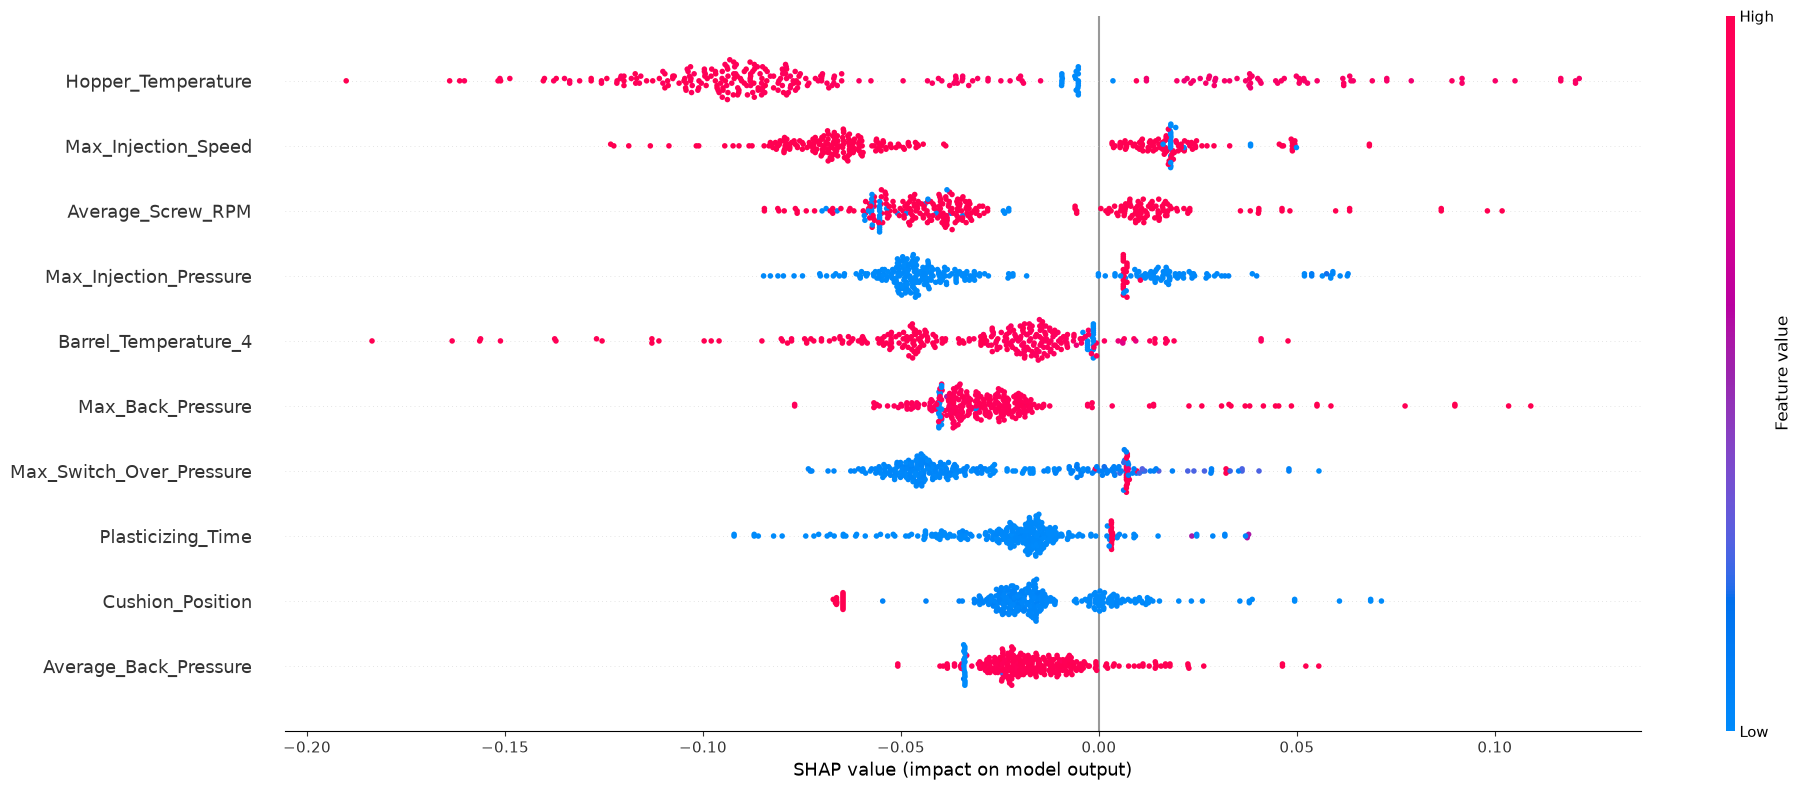

In [11]:
# ==========================================
# CELL 5: SHAP Explainability
# ==========================================
# We apply TreeExplainer to our Random Forest model to provide 
# physical root-cause explanations to the manufacturing operator.

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_active_learning)

# Normalise the SHAP output to a 2D (n_samples, n_features) matrix for the
# positive ("Fail") class. Older shap returns a list of per-class arrays, while
# shap >= 0.45 returns one (n_samples, n_features, n_classes) array.
if isinstance(shap_values, list):
    shap_values_to_plot = np.asarray(shap_values[1])
else:
    shap_values_to_plot = np.asarray(shap_values)
    if shap_values_to_plot.ndim == 3:
        shap_values_to_plot = shap_values_to_plot[:, :, 1]



# 1. Call the plot with show=False so it doesn't render yet
shap.summary_plot(
    shap_values_to_plot, 
    pd.DataFrame(X_active_learning, columns=feature_names), 
    max_display=10, 
    show=False
)

# 2. THE FIX: Grab the current figure and forcefully set its size in inches
fig = plt.gcf()
fig.set_size_inches(20,8) # Change width (12) and height (8) as needed

# 3. Add titles and render
# plt.title("Top Sensor Contributions to Anomalies (Intra-Cycle)\n\n\n")
plt.tight_layout()
plt.show()

Generating high-resolution SHAP beeswarm plot...


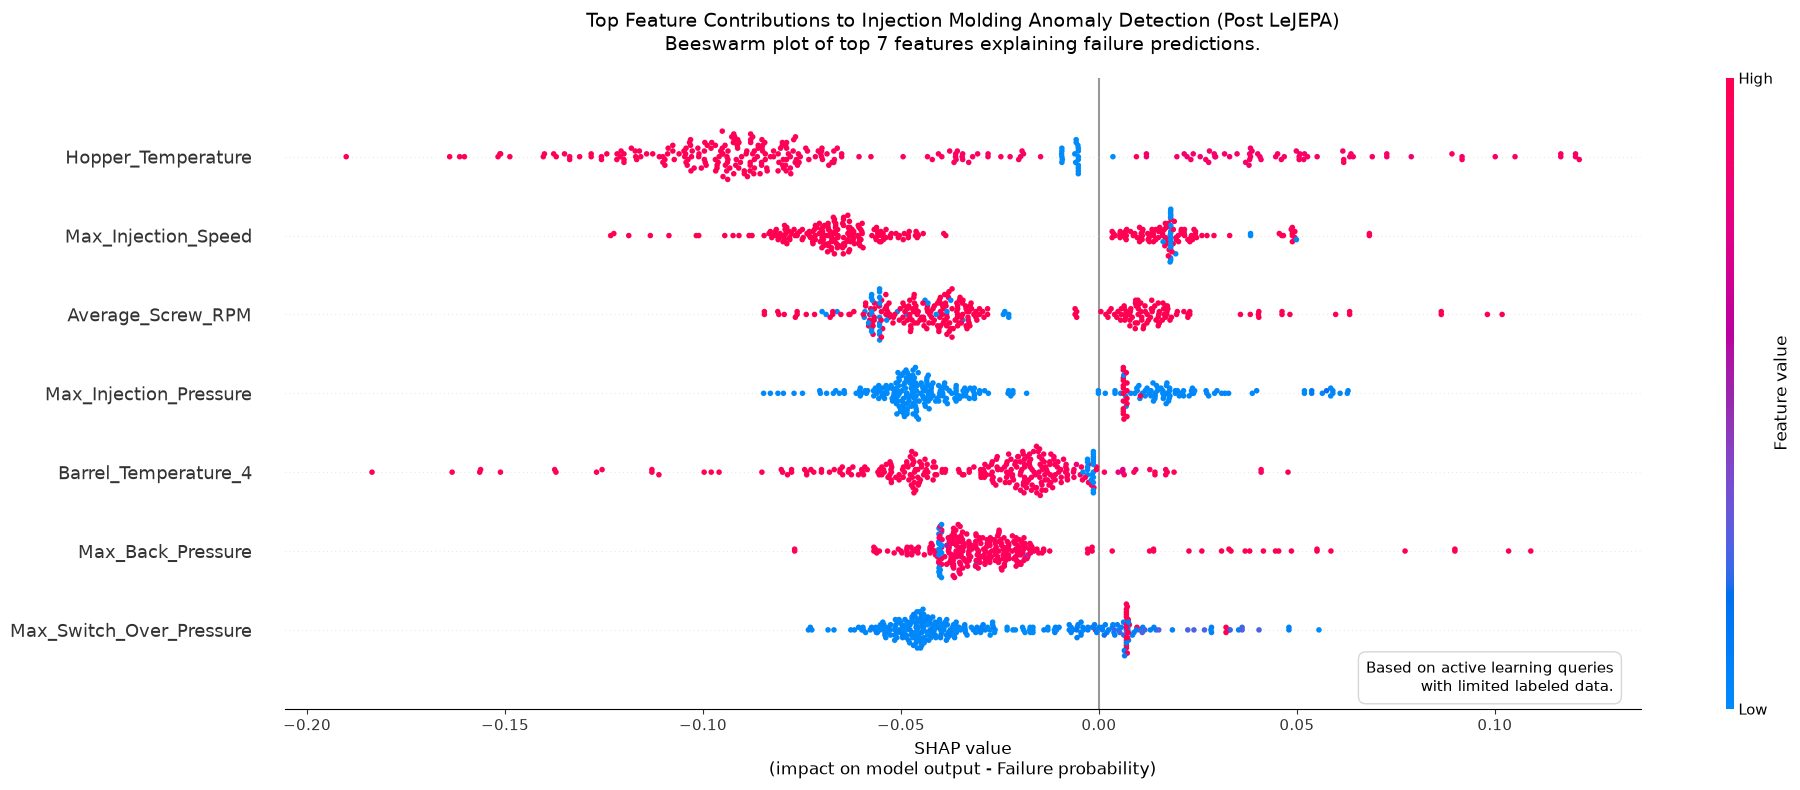

In [12]:
# ==========================================
# CELL 5: SHAP Explainability (Bulletproof Sizing)
# ==========================================
import matplotlib.pyplot as plt
import shap
import pandas as pd
import numpy as np

# 1. Initialize Explainer and calculate SHAP values
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_active_learning)

# Normalise the SHAP output to a 2D (n_samples, n_features) matrix for the
# positive ("Fail") class. Older shap returns a list of per-class arrays, while
# shap >= 0.45 returns one (n_samples, n_features, n_classes) array.
if isinstance(shap_values, list):
    shap_values_to_plot = np.asarray(shap_values[1])
else:
    shap_values_to_plot = np.asarray(shap_values)
    if shap_values_to_plot.ndim == 3:
        shap_values_to_plot = shap_values_to_plot[:, :, 1]

print("Generating high-resolution SHAP beeswarm plot...")

# 2. Force Matplotlib's global figure size (Double protection)
plt.rcParams['figure.figsize'] = [12, 8]
fig = plt.figure(figsize=(20, 8))
ax = plt.gca()

# 3. THE FIX: Set plot_size=None to stop SHAP from overriding the dimensions
shap.summary_plot(
    shap_values_to_plot, 
    pd.DataFrame(X_active_learning, columns=feature_names), 
    max_display=7, 
    plot_size=None,  # <--- This forces SHAP to respect our 12x8 figure size
    show=False
)

# 4. Add custom titles and labels
plt.title(
    "Top Feature Contributions to Injection Molding Anomaly Detection (Post LeJEPA)\n"
    "Beeswarm plot of top 7 features explaining failure predictions.", 
    fontsize=14, pad=20
)

ax.set_xlabel("SHAP value\n(impact on model output - Failure probability)", fontsize=12)

# 5. Add the active learning context text box
plt.text(
    0.98, 0.02, 
    "Based on active learning queries\nwith limited labeled data.", 
    horizontalalignment='right', 
    verticalalignment='bottom', 
    transform=ax.transAxes,
    fontsize=11,
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='lightgray', boxstyle='round,pad=0.5')
)

# 6. Final layout adjustments and render
plt.tight_layout()
plt.show()

# Reset rcParams back to default so it doesn't affect other notebook plots
plt.rcParams['figure.figsize'] = plt.rcParamsDefault['figure.figsize']

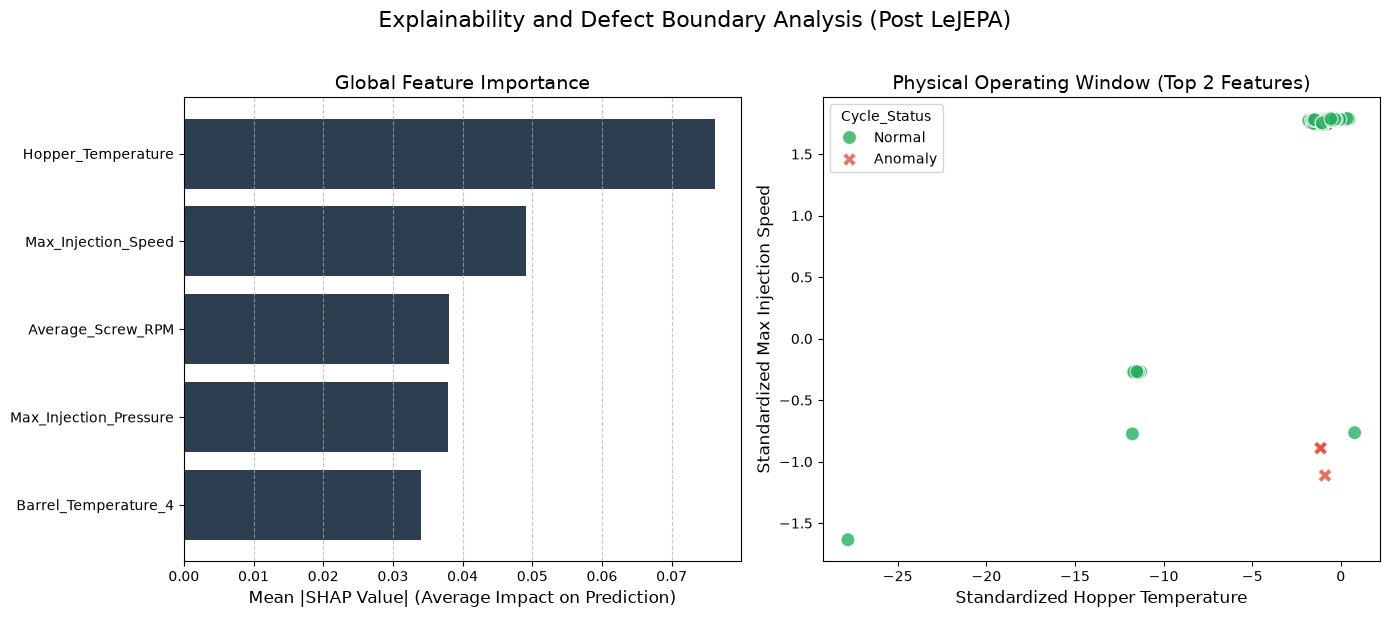

In [13]:
# ==========================================
# CELL 5: XAI & Operating Window (Dual Plot)
# ==========================================

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_active_learning)



# 1. Calculate Mean Absolute SHAP values for Global Importance
# (shap_values_to_plot is the 2D positive-class matrix built in the explainer cell)
shap_values_to_plot = np.asarray(shap_values_to_plot)
if shap_values_to_plot.ndim == 3:
    shap_values_to_plot = shap_values_to_plot[:, :, 1]

shap_abs_mean = np.abs(shap_values_to_plot).mean(axis=0)
assert shap_abs_mean.shape == (len(feature_names),), (
    f"Expected one importance per feature, got {shap_abs_mean.shape}"
)

# Rank the features and grab the top 5 for the bar chart
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': shap_abs_mean})
importance_df = importance_df.sort_values(by='Importance', ascending=True)
top5_df = importance_df.tail(5)

# The two most important features drive the operating-window scatter
feat_x, feat_y = importance_df['Feature'].iloc[-1], importance_df['Feature'].iloc[-2]

# 2. Prepare the DataFrame for the 2D Scatter Plot
X_al_df = pd.DataFrame(X_active_learning, columns=feature_names)
# Map 0 and 1 to readable labels for the legend
X_al_df['Cycle_Status'] = np.where(y_active_learning == 1, 'Anomaly', 'Normal')

# 3. Set up the Matplotlib figure with 2 subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- LEFT PLOT: SHAP Bar Chart ---
ax1.barh(top5_df['Feature'], top5_df['Importance'], color='#2C3E50')
ax1.set_xlabel('Mean |SHAP Value| (Average Impact on Prediction)', fontsize=12)
ax1.set_title('Global Feature Importance', fontsize=14)
ax1.grid(axis='x', linestyle='--', alpha=0.7)

# --- RIGHT PLOT: 2D Operating Window ---
sns.scatterplot(
    data=X_al_df,
    x=feat_x,
    y=feat_y,
    hue='Cycle_Status',
    hue_order=['Normal', 'Anomaly'],
    palette={'Normal': '#27AE60', 'Anomaly': '#E74C3C'}, # Colorblind-friendly Green/Red
    style='Cycle_Status',
    markers={'Normal': 'o', 'Anomaly': 'X'},
    s=100, # Marker size
    alpha=0.8,
    ax=ax2
)

ax2.set_title('Physical Operating Window (Top 2 Features)', fontsize=14)
ax2.set_xlabel(f"Standardized {feat_x.replace('_', ' ')}", fontsize=12)
ax2.set_ylabel(f"Standardized {feat_y.replace('_', ' ')}", fontsize=12)

# 4. Final layout adjustments
plt.suptitle('Explainability and Defect Boundary Analysis (Post LeJEPA)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
